# DS 542 Fall 2025 Project 2

Your task for this project to design and train a convolutional neural network classifying pictures of butterflies from [iNaturalist](https://www.inaturalist.org) by species.


## Background

The iNaturalist project crowdsources observations of wildlife including images, location, timestamp, and species identification.

Here is an example image from [an observation of a Monarch butterfly](https://www.inaturalist.org/observations/231456432).

![Danaus plexippus plexippus](https://inaturalist-open-data.s3.amazonaws.com/photos/411089128/medium.jpeg)


## Data

For this project, observations and images for many butterfly species were collected in a GitHub repository.

  https://github.com/DL4DS/butterflies

**Checking out this repository requires about 21GB of disk space.**
This repository is checked out on the Shared Compute Cluster (SCC) at `/projectnb/dl4ds/materials/datasets/butterflies`.

## Outline

1. Visualize species distribution and prepare to classify top 9 species.
2. Implement Torch DataSet and DataLoader objects to simplify data access.
3. Define model structure and select an appropriate loss function.
4. Implement a training loop and explain your choices.
5. Predict species for the test set.

## Modules

In [6]:
import pandas as pd
import torch
import numpy as np
import os 
import matplotlib.pyplot as plt
# Add any other imports you need

In [7]:
torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Part 1: Visualize species distribution and prepare to classify top 9 species.

### Plot a histogram of species in the training data set.

Don't worry about cleaning up possible duplicates.
Just use the species names as is.

In [8]:
data_dir = "/projectnb/dl4ds/materials/datasets/butterflies"

Index(['uuid', 'image_path', 'scientific_name'], dtype='object')


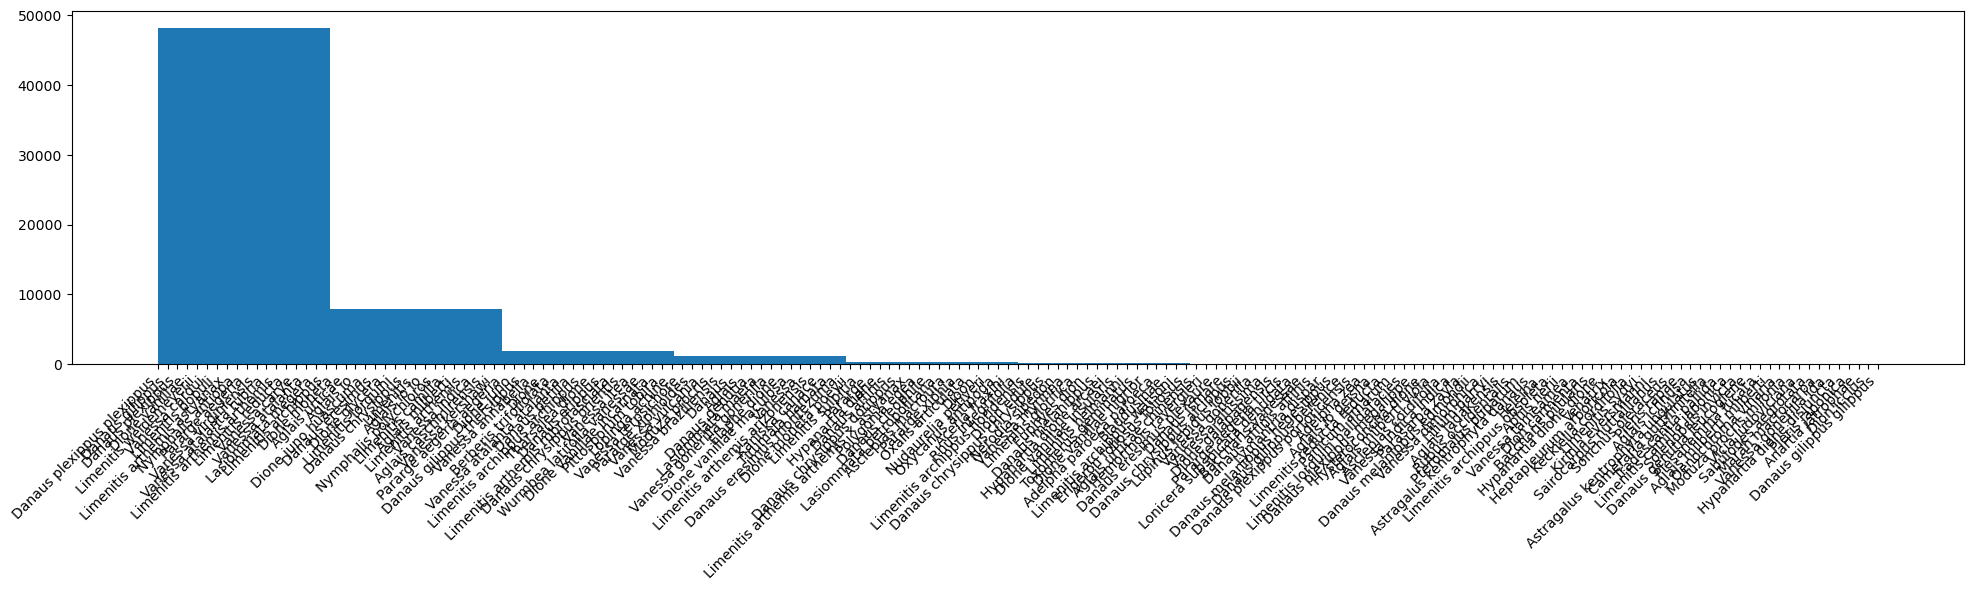

In [9]:
# YOUR CHANGES HERE

def import_data(t): 
    images = pd.read_csv(f"{data_dir}/{t}.csv")
    print(images.columns) 
    return images

df = import_data("train")
# counts = df['scientific_name'].value_counts()
# species_name = list(counts.index)
# species_value = list(counts)
plt.figure(figsize=(20, 6))
plt.hist(df['scientific_name'])
plt.xticks(rotation=45, ha='right') 
plt.tight_layout()
plt.show()

### Plot a histogram of the top 9 species plus an "Other" category for the other species.

Use the training data set again.

{'Danaus plexippus': 0, 'Vanessa atalanta': 1, 'Dione vanillae': 2, 'Aglais io': 3, 'Pararge aegeria': 4, 'Vanessa virginiensis': 5, 'Vanessa cardui': 6, 'Nymphalis antiopa': 7, 'Danaus gilippus': 8, 'Other': 9}
{0: 'Danaus plexippus', 1: 'Vanessa atalanta', 2: 'Dione vanillae', 3: 'Aglais io', 4: 'Pararge aegeria', 5: 'Vanessa virginiensis', 6: 'Vanessa cardui', 7: 'Nymphalis antiopa', 8: 'Danaus gilippus', 9: 'Other'}


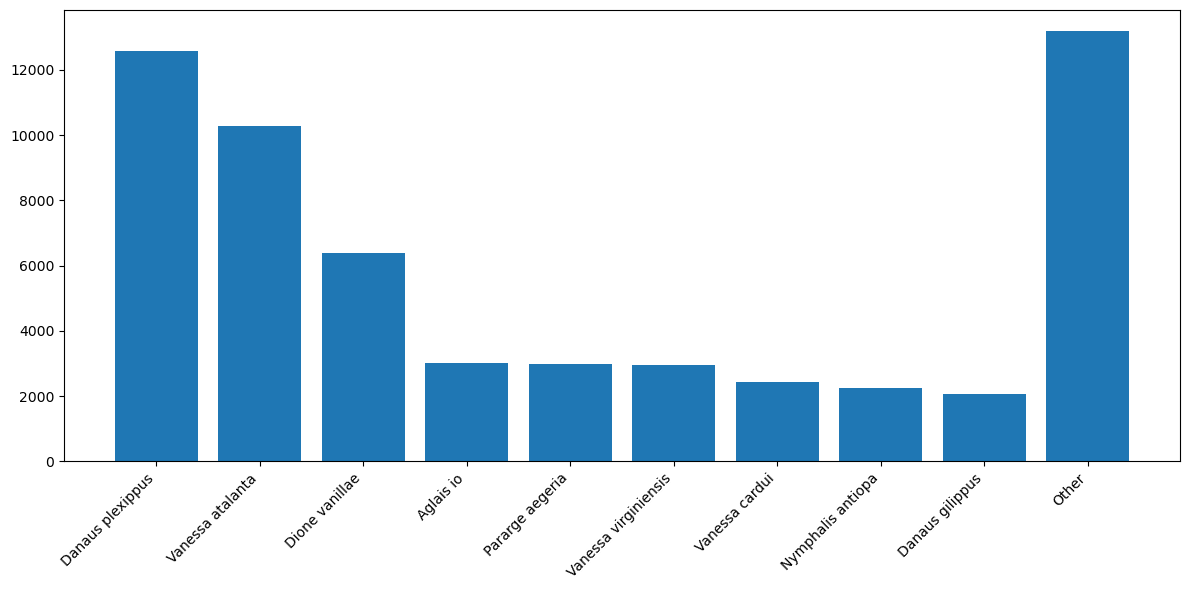

In [10]:
# YOUR CHANGES HERE

def find_top_10_species(df, name): 
    groups = df[name].value_counts()
    
    others_val = sum(list(groups)[10:]) 
    
    counts = list(groups)[0:10]
    counts[-1] = others_val

    species_name = list(groups.index)[0:10]
    species_name[-1] = "Other" 

    return species_name, counts 


train_species, counts = find_top_10_species(df=df, name="scientific_name")


name_to_id = {v: k for k, v in enumerate(train_species)}
print(name_to_id)
id_to_name = {v: k for k,v in name_to_id.items()}
print(id_to_name)

plt.figure(figsize=(12, 6))
plt.bar(train_species, counts)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Write files "train-onehot.csv" and "validation-onehot.csv".

These will facilitate your data management later.
The columns for both files should be `uuid` and `image_path` from either "train.csv" or "validation.csv", followed by the top 9 species in the training data set in order, followed by `other`.
The values for the species and `other` columns should all be zero or one.

In [11]:
import torch.nn.functional as F

species_name = list(train_species)
def convert_series_to_one_hot(df, name): 
    df = df.copy()
    df[name] = df[name].map(lambda x: "Other" if x not in species_name else x) 
    df["value"] = df[name].map(name_to_id) 
    vector_tensor = torch.Tensor(df['value']).long()
    one_hot_df = pd.DataFrame(F.one_hot(vector_tensor).detach().numpy()) 
    one_hot_df.columns = one_hot_df.columns.map(id_to_name)

    return df[['uuid', 'image_path']].merge(one_hot_df, on=df.index).drop('key_0', axis=1)


new_df = convert_series_to_one_hot(df, "scientific_name")
print(new_df)
new_df.to_csv("train-onehot.csv", index=False)

                                       uuid  \
0      5994c404-c52b-4833-ace9-eecdd76cf149   
1      6cb21298-a76e-4693-abc5-c5ddea93ffbe   
2      6f34b554-3cc9-4175-a9ec-13572e096e5c   
3      59aff41d-9a5f-40ec-84a5-bc422b4c8939   
4      9258b964-304e-4030-9c10-2477a66fd4e9   
...                                     ...   
59746  2d1dde7d-d541-4c5d-a532-dbc921bf3d8c   
59747  db58880b-a4fd-41c8-9de4-0a17f1cc84eb   
59748  52b557da-03bc-4d99-bba8-127e3a0a11a4   
59749  94ce9ecd-a1cf-4d5f-b4c0-5560a2f3a05f   
59750  4e2cadf9-a361-4394-8b70-b30cfb3747bb   

                                              image_path  Danaus plexippus  \
0      images-original/59/5994c404-c52b-4833-ace9-eec...                 0   
1      images-original/6c/6cb21298-a76e-4693-abc5-c5d...                 0   
2      images-original/6f/6f34b554-3cc9-4175-a9ec-135...                 1   
3      images-original/59/59aff41d-9a5f-40ec-84a5-bc4...                 0   
4      images-original/92/9258b964-304e-4030-

In [12]:
# YOUR CHANGES HERE
validation_df = import_data("validation") 

new_validation_df = convert_series_to_one_hot(validation_df, "scientific_name")
print(new_validation_df)
new_validation_df.to_csv('validation-onehot.csv', index=False) 


Index(['uuid', 'image_path', 'scientific_name'], dtype='object')
                                      uuid  \
0     f6a62380-4995-459a-989b-963c3c10935d   
1     6d7c97ec-f43e-4d06-81b4-e02a8f81b2d8   
2     0339f8a1-318b-4c80-b51f-cc0146537412   
3     6363770c-5772-4a1f-b252-5e43bfad2027   
4     6afd2eae-261b-4baa-9d84-5740c815bf15   
...                                    ...   
9995  bfe20120-da6b-4a8a-8ffc-76567009ba4f   
9996  690bbbd7-1e36-476e-a914-cb6f2d125a49   
9997  3589b5b1-d4ca-4fee-a60f-bebff40fb3fd   
9998  726e4ac2-c0a7-418e-b4c5-25375f93ac68   
9999  4331dea2-9077-4378-9b6a-a445fb034c37   

                                             image_path  Danaus plexippus  \
0     images-original/f6/f6a62380-4995-459a-989b-963...                 0   
1     images-original/6d/6d7c97ec-f43e-4d06-81b4-e02...                 0   
2     images-original/03/0339f8a1-318b-4c80-b51f-cc0...                 0   
3     images-original/63/6363770c-5772-4a1f-b252-5e4...                 0 

Submit "train-onehot.csv" and "validation-onehot.csv" in Gradescope.

Comment: The onehot encoding into files could have been skipped and instead the onehot encoding could have been handled by the DataSet subclass in part 2.
The auto-grader will check your files and give points after verifying their contents.
You should test submitting early to make sure that you have prepared the intended files.

## Part 2: Implement Torch DataSet and DataLoader objects to simplify data access.

Implement Torch [DataSet](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.Dataset) and [DataLoader](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader) objects to separate data loading issues from the training logic.

Implement an appropriate DataSet subclass for the training and validation data.
The class constructor should take in a filename ("train.csv" or "validation.csv") and load the corresponding data.
The `__getitem__` method should return a tuple with a tensor of a single image data and a tensor with the onehot encoding of the target value.

torch.Size([500, 375, 3])


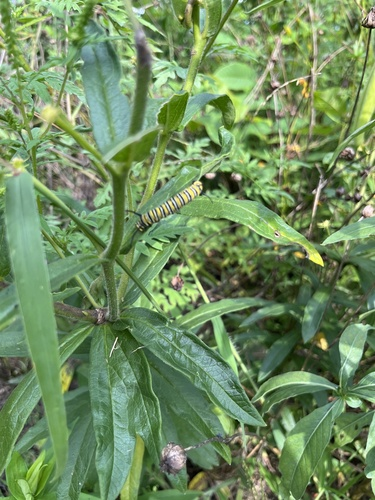

In [13]:
from PIL import Image
import os
import imageio.v2 as imageio


image_path = os.path.join(data_dir, df['image_path'].loc[0])
image = imageio.imread(image_path)

print(torch.Tensor(image).size())

Image.open(image_path)

In [14]:
# YOUR CHANGES HERE
from torch.utils.data import Dataset, DataLoader
        
class ButterflyDataset(Dataset): 
    def __init__(self, file_name, data_dir=data_dir): 
        df = pd.read_csv(f"{file_name}")
        species_names = ['Danaus plexippus', 'Vanessa atalanta', 'Dione vanillae', 'Aglais io', 'Pararge aegeria', 'Vanessa virginiensis', 'Vanessa cardui', 'Nymphalis antiopa', 'Danaus gilippus', 'Other']
        self.data_dir = data_dir 
        self.values = df[species_names].values
        self.x = df['image_path'].values
        self.cache = {}

    def __len__(self): 
        return len(self.x)

    def _retrieve_image(self, image_url): 
        if image_url in self.cache:
            return self.cache[image_url]

        img_path = os.path.join(self.data_dir, image_url)
        img = Image.open(img_path).convert("RGB")

        x = torch.tensor(np.array(img), device="cpu").float() / 255.0
        x = x.permute(2, 0, 1).float()

        self.cache[image_url] = x 
        return x

    def __getitem__(self, idx):
        x_tensor = self._retrieve_image(self.x[idx])
        return x_tensor, torch.Tensor(self.values[idx]).float()

Create a DataLoader object for the training data.

In [15]:
# YOUR CHANGES HERE

data = ButterflyDataset("train-onehot.csv")
loader = DataLoader(
        data,
        batch_size=32,
        shuffle=True,
)
print(len(loader)*32)

59776


In [16]:
val = ButterflyDataset("validation-onehot.csv")
val_loader = DataLoader(val, batch_size=254, shuffle=True) 
print(len(val_loader)*254)

10160


Explain any non-default parameter choices you made for the DataLoader.

YOUR ANSWER HERE

...

## Part 3: Define model structure and select an appropriate loss function.

Implement the model class for your convolutional neural network.
The final output of your model should be a tensor of probabilities for each of the ten species choices.

> Hint 1: refer to [project 1](https://github.com/DL4DS/sp2026/blob/main/static_files/assignments/project1.ipynb) for an example, albeit it is most likely much to simple a model.

> Hint 2: think about models we discussed recently in class and start with one of the popular ones.

> Hint 3: this problem may benefit from starting with a model pre-trained on ImageNet in which you then finetune on this dataset.

In [17]:
import warnings
import time 
HEIGHT = 500 
WIDTH = 375

In [18]:
# YOUR CHANGES HERE
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = ButterflyDataset("train-onehot.csv")
val=ButterflyDataset("validation-onehot.csv")
HEIGHT = 500 
WIDTH = 375
import os
import time
import warnings
import torch
from torch.utils.data import DataLoader
import livelossplot
import torcheval.metrics.functional

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 
class VisionModel(torch.nn.Module): 
    def __init__(self, num_layers, in_channels, out_channels, kernel_size, p_size, stride, data, val_data=None, device=device): 
        super().__init__()
        self.num_layers = num_layers
        self.data = data
        self.val_data = val_data
        self.in_channels = in_channels 
        self.out_channels = out_channels
        self.kernel_size = kernel_size
        self.stride = stride
        self.device = device
        self.p_size = p_size

        network = [] 
        network.append(torch.nn.Conv2d(in_channels=self.in_channels, out_channels=self.out_channels, kernel_size=self.kernel_size, stride=self.stride))
        network.append(torch.nn.BatchNorm2d(self.out_channels))
        network.append(torch.nn.ReLU())
        
        for _ in range(num_layers-1): 
            network.append(torch.nn.Conv2d(in_channels=self.out_channels, out_channels=self.out_channels, kernel_size=self.kernel_size, stride=self.stride)) 
            network.append(torch.nn.BatchNorm2d(self.out_channels))
            network.append(torch.nn.ReLU())
            
        network.append(torch.nn.AdaptiveAvgPool2d((self.p_size, self.p_size)))
        network.append(torch.nn.Flatten()) 
        network.append(torch.nn.Linear(self.p_size * self.p_size * self.out_channels, 10))
        network.append(torch.nn.Softmax(dim=1)) 
        
        self.network = torch.nn.DataParallel(torch.nn.Sequential(*network)) 
        
    def _save_parameters(self, name, directory="results"): 
        os.makedirs(directory, exist_ok=True)
        path = os.path.join(os.getcwd(), directory, f"{name}_model_param.pth") 
        torch.save(self.network.module.state_dict(), path)
        return path 
        
    def _init_data_loader(self, batch_size=256, shuffle=True): 
        return DataLoader(self.data, batch_size=batch_size, shuffle=shuffle) 
    def _init_val_loader(self, batch_size=1028, shuffle=False): 
        return DataLoader(self.val_data, batch_size, shuffle) 

    def forward(self, x): 
        if not isinstance(x, torch.Tensor): 
            x = torch.Tensor(x) 

        if len(x.size()) == 4 and x.size(1) != self.in_channels: 
            print(x.size())
            warnings.warn("Tensor shape mismatch: expected [batch, channels, H, W]")
        return self.network(x)

    def train_model(self, lr=1e-4, weight_decay=0, num_epochs=100, criterion=torch.nn.BCEWithLogitsLoss(), batch_size=256, shuffle=True):
        if torch.cuda.is_available():
            self.network.cuda()
        
        optimizer = torch.optim.Adam(self.network.parameters(), lr=lr, weight_decay=weight_decay)
        train_loader = self._init_data_loader(batch_size=batch_size, shuffle=shuffle)
        val_loader = self._init_val_loader(batch_size=batch_size, shuffle=False) if self.val_data is not None else None
        
        liveloss = livelossplot.PlotLosses()

        best_val_loss = float('inf')
        for epoch in range(num_epochs):
            self.network.train()
            running_train_loss = 0.0
            for i, (x_batch, y_batch) in enumerate(train_loader):
                x_batch = x_batch.to(self.device)
                y_batch = y_batch.to(self.device)

                optimizer.zero_grad(set_to_none=True)
                y_pred = self.forward(x_batch)
                loss = criterion(y_pred, y_batch)
                print(f" Epoch: {epoch} | Batch {i} of {len(train_loader)} | Loss: {loss}") 
                loss.backward()
                optimizer.step()

                running_train_loss += loss.item()
            
            avg_train_loss = running_train_loss / len(train_loader)
            updates = {"loss": avg_train_loss}

            if val_loader is not None:
                self.network.eval()
                val_loss_total = 0.0
                with torch.no_grad():
                    for x_val, y_val in val_loader:
                        x_val = x_val.to(self.device)
                        y_val = y_val.to(self.device)
                        y_val_pred = self.forward(x_val)
                        val_loss_total += criterion(y_val_pred, y_val).item()
                avg_val_loss = val_loss_total / len(val_loader)
                updates["val_loss"] = avg_val_loss

                # save best model
                if avg_val_loss < best_val_loss:
                    best_val_loss = avg_val_loss
                    self._save_parameters(name=str(time.time()))
            
            # update liveloss plot
            liveloss.update({k: torch.tensor(v) for k, v in updates.items()})
            liveloss.send()
        
        return self

vision = VisionModel(data=data, num_layers=5, in_channels=3, out_channels=3, kernel_size=2, p_size=5, stride=2)
d = vision._init_data_loader(batch_size=1, shuffle=False) 
x = next(iter(d))[0] 
with torch.no_grad(): 
    out = vision.forward(x) 
    print(out) 

del x
del d
del vision
del out

tensor([[0.0796, 0.0619, 0.0973, 0.0803, 0.1633, 0.0768, 0.0997, 0.1073, 0.1063,
         0.1276]], device='cuda:0')


In [19]:
# just testing this works
vision = VisionModel(data=data, num_layers=5, in_channels=3, out_channels=3, kernel_size=2, p_size=5, stride=2)
d = vision._init_data_loader(batch_size=1, shuffle=False)

x = next(iter(d))[0]
with torch.no_grad(): 
    out = vision.forward(x)
    print("Model probabilities:", out)
    print("Tensor size:", out.size())
del x 
del d
del vision
del out 

Model probabilities: tensor([[0.1053, 0.1018, 0.1190, 0.0769, 0.1066, 0.0844, 0.0897, 0.1482, 0.0619,
         0.1063]], device='cuda:0')
Tensor size: torch.Size([1, 10])


Explain your choices for the shapes in each convolutional layer of your model.

YOUR ANSWER HERE

I first transformed the input from a [batch, 500 (height), 375 (width), 3 (channel)] by permuting the tensor into [batch, 3 (channel), 500 height, 375 width] so that I can feed it into the first convolutional layer which has a kernel size of 2. Each convolutional layer uses a kernel size of 2 and stride of 2, which aggressively downsamples the spatial dimensions of the input by approximately a factor of 2 per layer. This allows the model to rapidly reduce computational cost while extracting increasingly abstract spatial features. After five layers, the spatial resolution is reduced significantly, and an adaptive average pooling layer ensures a fixed output size of 5×5 regardless of input dimensions. Though, in hindsight, the the stride of 2 in the beginning may have been too rapid of a downsizing, so I could experiment with stride of 1 for now. 

Explain your choices for the channels in each convolutional layer of your model.

YOUR ANSWER HERE

The model maintains a constant number of channels 5 across all convolutional layers. This simplifies the architecture and reduces computational overhead, but limits the representational capacity of the network. Unlike standard CNNs that increase channel depth to capture more complex features at deeper layers, this design constrains the model to a small set of feature maps though greater than the original number of channels to ideally capture more richer hierarchical transformations. 

Pick and define a loss function for your model.
Feel free to use an existing Torch function.

In [20]:
# YOUR CHANGES HERE
criterion = torch.nn.CrossEntropyLoss()

Explain your choice of loss function.
One sentence should suffice.

YOUR ANSWER HERE

I chose the `torch.nn.CrossEntropyLoss()`  function because it is a suitable loss function for classification tasks where the output of the neural network are unnormalized logit values (i.e., output of a linear layer not after softmax for multi-class classification or sigmoid for binary classification). 

## Part 4: Implement a training loop and explain your choices.

Implement and run an appropriate training loop.
Plot accuracy and loss for the training and validation sets for each epoch.
Plot a summary of the gradients of your choice for each epoch.

In [21]:
SPECIES_NAMES=train_species
print(SPECIES_NAMES)
tensor_obj = torch.Tensor(new_validation_df[SPECIES_NAMES].values)
new_validation_df['outcome'] = torch.argmax(tensor_obj, dim=1).reshape(-1,)
print(new_validation_df['outcome'])

['Danaus plexippus', 'Vanessa atalanta', 'Dione vanillae', 'Aglais io', 'Pararge aegeria', 'Vanessa virginiensis', 'Vanessa cardui', 'Nymphalis antiopa', 'Danaus gilippus', 'Other']
0       5
1       9
2       1
3       1
4       9
       ..
9995    9
9996    1
9997    2
9998    0
9999    0
Name: outcome, Length: 10000, dtype: int64


In [24]:
from torchvision import models
import os
import time
import warnings
import torch
from torch.utils.data import DataLoader
import livelossplot
import torcheval.metrics.functional

model = models.alexnet(pretrained=True)


device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') 

class FinetunedAlexNet():
    def __init__(self, model, train_data, val_data, device=device):
        self.model = model
        self.train_data = train_data
        self.val_data = val_data
        self.device = device
 
        self._set_finetune_alexnet()
        self.model.to(self.device)
 
    def _set_finetune_alexnet(self):
        print("Disabling gradient tracking and flow for all parameters")
        for param in self.model.parameters():
            param.requires_grad = False
 
        for name, param in self.model.named_parameters():
            if name.startswith('classifier'):
                print(f"Enabling gradient tracking and flow for {name}")
                param.requires_grad = True
        self.model.classifier.add_module("7", torch.nn.ReLU(inplace=True))
        self.model.classifier.add_module("8", torch.nn.Linear(1000, 10))
        print(self.model)
 
    def _save_parameters(self, name, directory="results"):
        os.makedirs(directory, exist_ok=True)
        path = os.path.join(os.getcwd(), directory, f"{name}_model_param.pth")
        # Support both plain model and DataParallel-wrapped model
        state = self.model.module.state_dict() if hasattr(self.model, 'module') else self.model.state_dict()
        torch.save(state, path)
        return path
 
    def _init_data_loader(self, batch_size=256, shuffle=True):
        return DataLoader(self.train_data, batch_size=batch_size, shuffle=shuffle)
 
    def _init_val_loader(self, batch_size=1028, shuffle=False):
        return DataLoader(self.val_data, batch_size, shuffle)
 
    def _get_mini_val_batch(self, mini_val_size=256):
        """Pull a single shuffled batch from val_data directly onto the GPU."""
        loader = self._init_val_loader(batch_size=mini_val_size, shuffle=True)
        x_val, y_val = next(iter(loader))
        return x_val.to(self.device), y_val.to(self.device)
     
    def forward(self, x, one_hot=True):
        y = self.model(x)
        return y if one_hot else torch.argmax(y, dim=-1)
 
    def _evaluate_loader(self, loader, criterion):
        self.model.eval()
        total_loss = 0.0
        correct = 0
        total = 0
    
        with torch.no_grad():
            for x_val, y_val in loader:
                x_val = x_val.to(self.device)
                y_val = y_val.to(self.device)
    
                preds = self.forward(x_val) 
                loss  = criterion(preds, y_val)    
                total_loss += loss.item()
    
                predicted = torch.argmax(preds, dim=-1)
                y_idx     = torch.argmax(y_val, dim=-1) if y_val.dim() > 1 else y_val 
                correct  += (predicted == y_idx).sum().item()   
                total    += y_val.size(0)
    
        return total_loss / len(loader), correct / total if total > 0 else 0.0
    def _mini_validate(self, loader, criterion, num_batches=8):
        """
        Run validation on `num_batches` batches from loader (e.g., 8 batches of 256 = 2048 samples).
        """
        self.model.eval()
    
        total_loss = 0.0
        total_correct = 0
        total_samples = 0
    
        with torch.no_grad():
            for i, (x_val, y_val) in enumerate(loader):
                if i >= num_batches:
                    break
    
                x_val = x_val.to(self.device)
                y_val = y_val.to(self.device)
    
                preds = self.forward(x_val)
                loss = criterion(preds, y_val)
    
                total_loss += loss.item()
    
                predicted = torch.argmax(preds, dim=-1)
                y_idx = torch.argmax(y_val, dim=-1) if y_val.dim() > 1 else y_val
    
                total_correct += (predicted == y_idx).sum().item()
                total_samples += y_val.size(0)
    
        avg_loss = total_loss / num_batches
        avg_acc = total_correct / total_samples if total_samples > 0 else 0.0

        return avg_loss, avg_acc
 
    def train_model(
        self,
        num_epochs=10,
        lr=1e-4,
        wd=0.0,
        criterion=torch.nn.CrossEntropyLoss(),
        batch_size=256,
        mini_val_size=2048, #samples for the every-10-batch val check
        mini_val_every_n_batches=10 # how often (in batches) to run the mini-val
    ):
        train_loader = self._init_data_loader(batch_size=batch_size, shuffle=True)
        val_loader = self._init_val_loader(batch_size=batch_size)
 
        optimizer = torch.optim.Adam(
            filter(lambda p: p.requires_grad, self.model.parameters()),
            lr=lr,
            weight_decay=wd
        )
 
        liveloss = livelossplot.PlotLosses()
        best_val_loss = float('inf')
        global_step  = 0
        try: 
            for epoch in range(num_epochs):
                self.model.train()
                epoch_train_loss = 0.0
                epoch_correct = 0
                epoch_total = 0
     
                for i, (x_batch, y_batch) in enumerate(train_loader):
                    x_batch = x_batch.to(self.device)
                    y_batch = y_batch.to(self.device)
     
                    optimizer.zero_grad(set_to_none=True)
                    preds = self.forward(x_batch)
                    loss  = criterion(preds, y_batch)
     
                    loss.backward()
                    optimizer.step()
     
                    batch_loss = loss.item()
                    predicted  = torch.argmax(preds.detach(), dim=-1)
                    y_idx = torch.argmax(y_batch, dim=-1) if y_batch.dim() > 1 else y_batch
                    batch_correct = (predicted == y_idx).sum().item()
                    batch_acc = batch_correct / y_batch.size(0)
                     
                    epoch_train_loss += batch_loss
                    epoch_correct += batch_correct
                    epoch_total += y_batch.size(0)
                    global_step += 1
     
                    print(f"Epoch {epoch} | Batch {i}/{len(train_loader)} | "
                          f"loss={batch_loss:.4f} | acc={batch_acc:.4f}")
     
                    liveloss.update({
                        "batch_loss": batch_loss,
                        "batch_accuracy": batch_acc,
                    })
                    liveloss.send()
    
                    if (i + 1) % mini_val_every_n_batches == 0:
                        mini_val_loss, mini_val_acc = self._mini_validate(
                            val_loader,
                            criterion,
                            num_batches=mini_val_size // batch_size  # 2048 / 256 = 8
                        )
                    
                        print(f"Mini-Validation step={global_step} | "
                              f"val_loss={mini_val_loss:.4f} | val_acc={mini_val_acc:.4f}")
                    
                        liveloss.update({
                            "mini_val_loss": mini_val_loss,
                            "mini_val_accuracy": mini_val_acc,
                        })
                        liveloss.send()
                    
                        if mini_val_loss < best_val_loss:
                            best_val_loss = mini_val_loss
                            saved_path = self._save_parameters(name=f"best_step{global_step}")
                            print(f"New best val_loss={best_val_loss:.4f} - saved to {saved_path}")
                    
                        self.model.train()
     
                avg_train_loss = epoch_train_loss / len(train_loader)
                avg_train_acc  = epoch_correct / epoch_total if epoch_total > 0 else 0.0
     
                full_val_loss, full_val_acc = self._evaluate_loader(val_loader, criterion)
     
                if full_val_loss < best_val_loss:
                    best_val_loss = full_val_loss
                    saved_path = self._save_parameters(name=f"best_epoch{epoch}")
                    print(f"New best epoch val_loss={best_val_loss:.4f}: saved to {saved_path}")
     
                liveloss.update({
                    "val_loss": full_val_loss,
                    "val_accuracy": full_val_acc,
                })
                liveloss.send()
     
                print(f"\nEpoch {epoch} summary: "
                      f"train_loss={avg_train_loss:.4f} train_acc={avg_train_acc:.4f} | "
                      f"val_loss={full_val_loss:.4f} val_acc={full_val_acc:.4f}\n")
     
                self.model.train()
        except KeyboardInterrupt: 
            print("Ended training early") 
     
        return self
        
ftmodel = FinetunedAlexNet(model=model, train_data=data, val_data=val) 
d = ftmodel._init_data_loader(batch_size=1, shuffle=False)

x = next(iter(d))[0]
with torch.no_grad(): 
    out = ftmodel.forward(x.to(device))
    print("Model probabilities:", out)
    print("Tensor size:", out.size())
    
del x 
del d
del ftmodel
del out 

Disabling gradient tracking and flow for all parameters
Enabling gradient tracking and flow for classifier.1.weight
Enabling gradient tracking and flow for classifier.1.bias
Enabling gradient tracking and flow for classifier.4.weight
Enabling gradient tracking and flow for classifier.4.bias
Enabling gradient tracking and flow for classifier.6.weight
Enabling gradient tracking and flow for classifier.6.bias
AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1

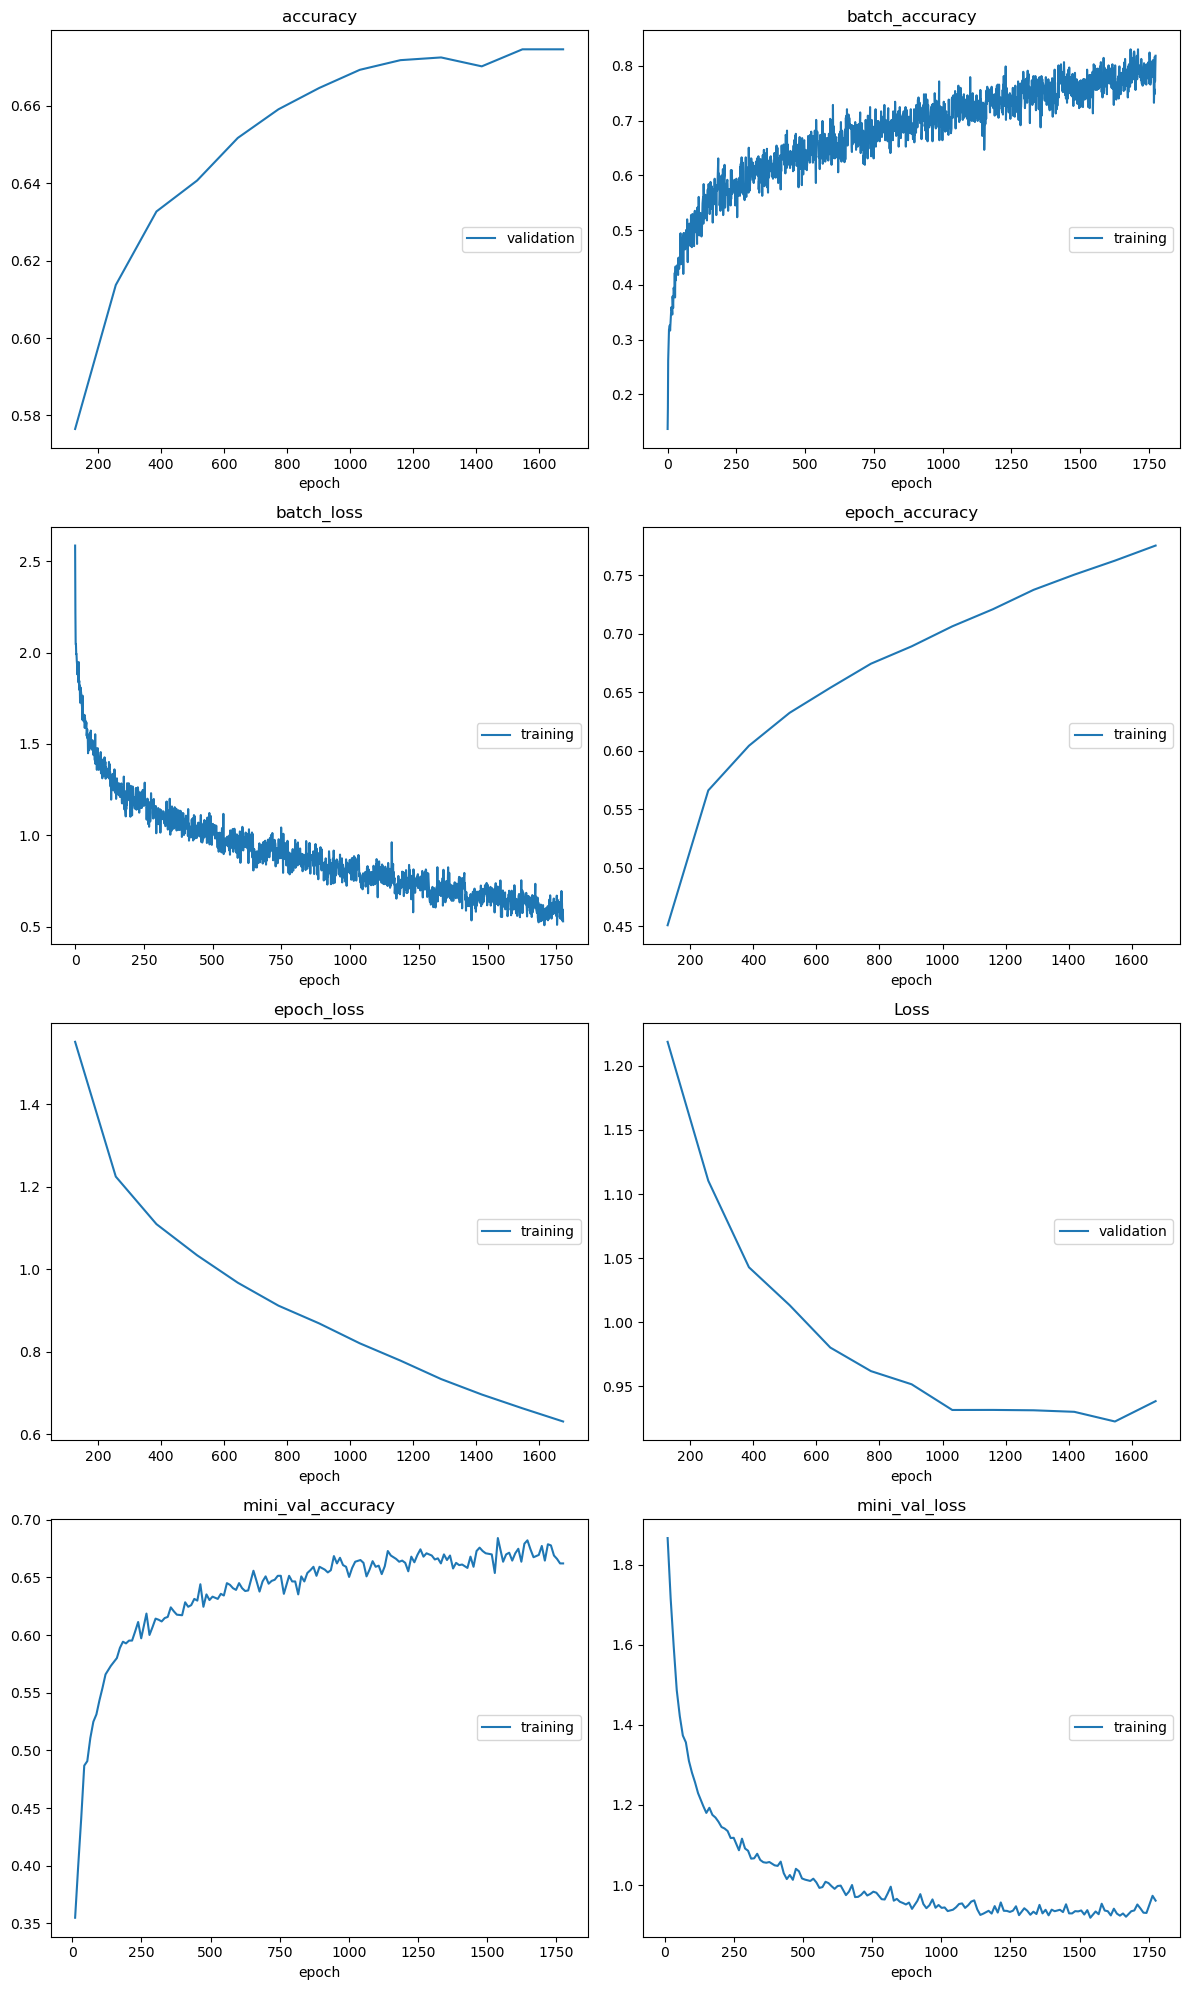

accuracy
	validation       	 (min:    0.577, max:    0.675, cur:    0.675)
batch_accuracy
	training         	 (min:    0.137, max:    0.830, cur:    0.818)
batch_loss
	training         	 (min:    0.508, max:    2.585, cur:    0.530)
epoch_accuracy
	training         	 (min:    0.451, max:    0.775, cur:    0.775)
epoch_loss
	training         	 (min:    0.631, max:    1.551, cur:    0.631)
Loss
	validation       	 (min:    0.923, max:    1.219, cur:    0.938)
mini_val_accuracy
	training         	 (min:    0.355, max:    0.684, cur:    0.662)
mini_val_loss
	training         	 (min:    0.918, max:    1.867, cur:    0.961)
Ended training early


In [23]:
ftmodel = FinetunedAlexNet(model=model, train_data=data, val_data=val) 
ftmodel.train_model(num_epochs=20, lr=1e-4, wd=1e-4, criterion=torch.nn.CrossEntropyLoss(), batch_size=512)

## Part 5: Predict species for the test set.

Use your model to predict probabilities for each of the species choices.

In [ ]:
### NOTE FOR PROF: There are a lot of different graphs because I made a few mistakes by reporting too many different metrics for the graphs. Please ignore those graphs 
### NOTE FOR PROF: However, I should note since training epoch took a long time and it did not yield very informative outputs, I spent more time 
### NOTE FOR PROF: 

In [25]:
import torch
import pandas as pd
from tqdm import tqdm
from PIL import Image
import os
import numpy as np

def predict_probabilities(model, df, data_dir, device=device):
    """
    Args:
        model: trained VisionModel
        df: DataFrame with at least column 'image_path'
        data_dir: root folder for images
        device: 'cuda' or 'cpu'
    
    Returns:
        DataFrame with predicted probabilities for each butterfly species
    """
    
    model.eval()  # set to eval mode
    species_names = ['Danaus plexippus', 'Vanessa atalanta', 'Dione vanillae', 'Aglais io',
                     'Pararge aegeria', 'Vanessa virginiensis', 'Vanessa cardui',
                     'Nymphalis antiopa', 'Danaus gilippus', 'Other']
    
    results = []

    with torch.no_grad():
        for _, row in tqdm(df.iterrows(), total=len(df)):
            img_path = os.path.join(data_dir, row['image_path'])
            try:
                img = Image.open(img_path).convert("RGB")
            except:
                print("SKIPPING MISSING", img_path)
                continue
            
            # normalize and convert to tensor
            x = torch.tensor(np.array(img)).float() / 255.0
            x = x.permute(2, 0, 1).unsqueeze(0)  # add batch dim
            
            x = x.to(device)
            preds = model(x)  # raw logits if trained with CrossEntropyLoss
            
            # Convert logits to probabilities
            probs = torch.softmax(preds, dim=1).cpu().numpy()[0]
            
            row_result = {'filename': row['image_path']}
            for i, name in enumerate(species_names):
                row_result[name] = probs[i]
            
            results.append(row_result)
    
    return pd.DataFrame(results)

Save your predictions to "test-predictions.csv" with columns `uuid`, the top 9 species and `other`.

In [ ]:
# Your changes here 
test_df = import_data("test") 

vision = FinetunedAlexNet(model=model, train_data=data, val_data=val)

vision.model.load_state_dict(
    torch.load("results/best_step1397_model_param.pth", map_location=device)
)
vision.model.to(device)
vision.model.eval()

test_pred_df = predict_probabilities(
    model=vision.model, 
    df=test_df, 
    data_dir=data_dir, 
    device=device
)

test_pred_df.to_csv("results/test-predictions.csv", index=False)

Index(['uuid', 'image_path'], dtype='object')
Disabling gradient tracking and flow for all parameters
Enabling gradient tracking and flow for classifier.1.weight
Enabling gradient tracking and flow for classifier.1.bias
Enabling gradient tracking and flow for classifier.4.weight
Enabling gradient tracking and flow for classifier.4.bias
Enabling gradient tracking and flow for classifier.6.weight
Enabling gradient tracking and flow for classifier.6.bias
Enabling gradient tracking and flow for classifier.8.weight
Enabling gradient tracking and flow for classifier.8.bias
AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d

 12%|█▏        | 1237/10000 [00:25<03:27, 42.26it/s]

Submit "test-predictions.csv" to Gradescope.

## Part 6: Submit Your Notebook

Submit your notebook to Gradescope.

## Follow Up

Make sure to check the immediate auto-grader feedback in Gradescope.
It will let you know if your file formats are correct and help you catch some avoidable mistakes.